# Assignment 5 – KNN with 10-Fold Cross-Validation & Grid Search
**AIS.ba Supervised Machine Learning SS2026**

This notebook revisits Assignment 2 and applies 10-fold cross-validation with GridSearchCV to find the optimal k for the KNN classifier on Dataset 1.

---

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

random_state = 42
np.random.seed(random_state)

k_values = list(range(1, 52, 2))
print(f"k values to test: {k_values}")
print(f"Number of k values: {len(k_values)}")

k values to test: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51]
Number of k values: 26


---
## Part A – Revisited Assignment 2 (corrected baseline)

The code below reproduces the Assignment 2 solution with correct dataset partitioning and scaling (scaler fitted only on training data, then applied to test data).

### A.1 Load & Explore Dataset

In [ ]:
# load the dataset and observe the first few rows and the shape of the dataset
df = pd.read_csv("DataSet1.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (200, 3)


,x1,x2,y
0,0.914806,0.885118,1
1,0.937075,0.517111,1
2,0.286140,0.851931,0
3,0.830448,0.442796,1
4,0.641746,0.157880,1


In [3]:
df.describe()

,x1,x2,y
count,200.000000,200.000000,200.000000
mean,0.522216,0.471997,0.590000
std,0.292024,0.292630,0.493068
min,0.000239,0.002378,0.000000
25%,0.258303,0.211678,0.000000
50%,0.555413,0.452307,1.000000
75%,0.760785,0.721522,1.000000
max,0.988892,0.996553,1.000000


Class distribution
y
1    118
0     82
Name: count, dtype: int64


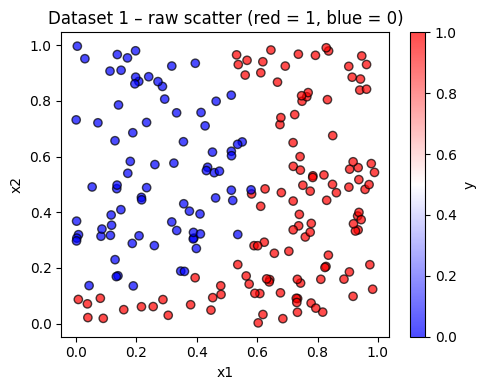

In [4]:
# let us observe the class distribution of this dataset closely
print("Class distribution")
print(df['y'].value_counts())

plt.figure(figsize=(5, 4))
plt.scatter(df['x1'], df['x2'], c=df['y'], cmap='bwr', edgecolors='k', alpha=0.7)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset 1 – raw scatter (red = 1, blue = 0)')
plt.colorbar(label='y')
plt.tight_layout()
plt.show()

### A.2 Train-Test Split & Scaling (corrected)

> **Key correction:** The `StandardScaler` is fitted **only on the training set** (`fit_transform`), and the same fitted scaler is **applied** (`.transform`) to the test set. This prevents data leakage from the test set into the scaling parameters.

In [6]:
X = df[['x1', 'x2']]
y = df['y']

# let's apply train-test split before any scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# check the sizes of the resulting sets
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# first of all we will fit the scaler on training data only, then transform both sets
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Train size: 140
Test size: 60


### A.3 Performing K-Nearest Neighbor on Cleaned Data + Evaluation of the Test Set

In [ ]:
results_baseline = [] # let us store the results for each k value in a list of dictionaries, 
                      # then we will convert it to a DataFrame for better visualization.

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train) # fit the model on the scaled training set
    acc = accuracy_score(y_test, knn.predict(X_test_scaled)) # predict accuracy on the scaled test set
    results_baseline.append({'k': k, 'accuracy': acc, 'error': 1 - acc}) # compare accuracy and error values for each k value

df_baseline = pd.DataFrame(results_baseline) # convert the list of dictionaries to a DataFrame
best_baseline = df_baseline.loc[df_baseline['accuracy'].idxmax()] 
print(df_baseline.to_string(index=False))

 k  accuracy    error
 1  0.983333 0.016667
 3  0.966667 0.033333
 5  0.950000 0.050000
 7  0.966667 0.033333
 9  0.983333 0.016667
11  0.983333 0.016667
13  0.983333 0.016667
15  0.983333 0.016667
17  0.983333 0.016667
19  0.983333 0.016667
21  0.966667 0.033333
23  0.950000 0.050000
25  0.966667 0.033333
27  0.966667 0.033333
29  0.966667 0.033333
31  0.966667 0.033333
33  0.966667 0.033333
35  0.966667 0.033333
37  0.966667 0.033333
39  0.966667 0.033333
41  0.966667 0.033333
43  0.966667 0.033333
45  0.966667 0.033333
47  0.966667 0.033333
49  0.950000 0.050000
51  0.950000 0.050000


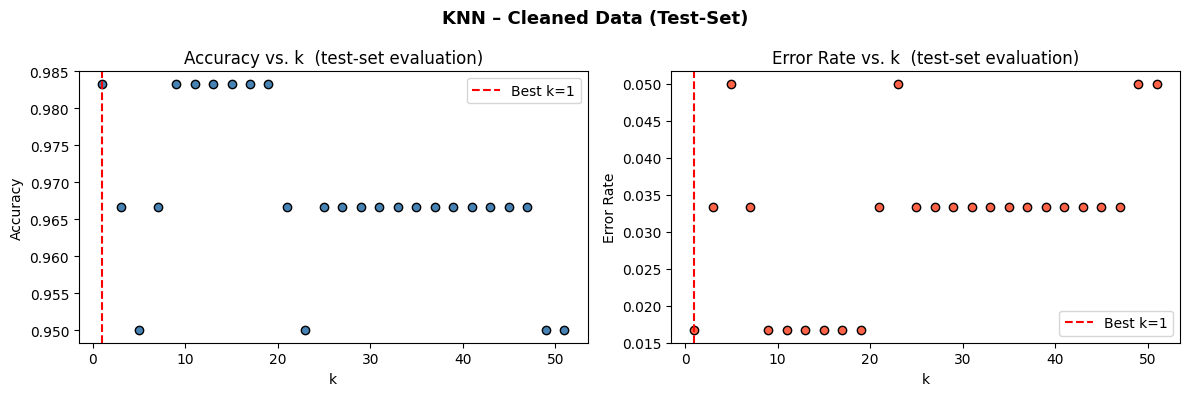

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_baseline['k'], df_baseline['accuracy'], color='steelblue', edgecolors='k')
axes[0].axvline(best_baseline['k'], color='red', linestyle='--', label=f"Best k={int(best_baseline['k'])}")
axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs. k  (test-set evaluation)')
axes[0].legend()

axes[1].scatter(df_baseline['k'], df_baseline['error'], color='tomato', edgecolors='k')
axes[1].axvline(best_baseline['k'], color='red', linestyle='--', label=f"Best k={int(best_baseline['k'])}")
axes[1].set_xlabel('k'); axes[1].set_ylabel('Error Rate')
axes[1].set_title('Error Rate vs. k  (test-set evaluation)')
axes[1].legend()

plt.suptitle('KNN – Cleaned Data (Test-Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Best k (test-set): 1
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.97      1.00      0.99        33

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



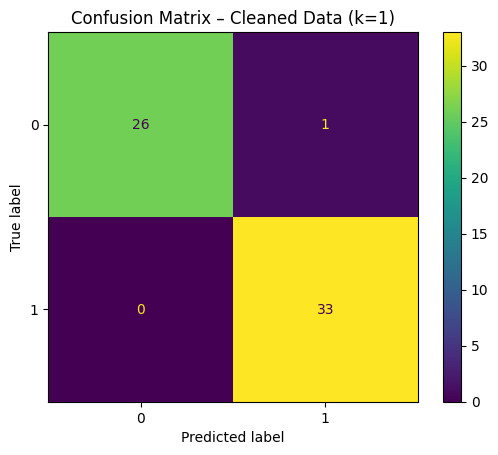

In [9]:
# now we will fit the best model on the training set,
# and evaluate it on the test set to see the detailed classification report and confusion matrix

best_k_baseline = int(best_baseline['k'])
knn_best = KNeighborsClassifier(n_neighbors = best_k_baseline)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled) 

print(f"Best k (test-set): {best_k_baseline}")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f'Confusion Matrix – Cleaned Data (k={best_k_baseline})')
plt.show()

### A.4 Analysis with 20% Flipped Training Labels

In [10]:
np.random.seed(42)
y_train_noisy = y_train.copy() # let us create a copy of training labels to introduce noise, 
                               # we will keep the original y_train for later comparison
                                
flip_mask = np.random.rand(len(y_train_noisy)) < 0.2 
y_train_noisy.iloc[flip_mask] = 1 - y_train_noisy.iloc[flip_mask]
print(f"Labels flipped: {flip_mask.sum()} out of {len(y_train_noisy)}")

Labels flipped: 35 out of 140


In [11]:
results_noisy_labels = []  # let us store the results for each k value in alist of dictionaries

for k in k_values:  # create a loop to fit and evaluate the model for each k value
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_noisy)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    results_noisy_labels.append({'k': k, 'accuracy': acc, 'error': 1 - acc})

df_noisy_labels = pd.DataFrame(results_noisy_labels)
best_noisy_labels = df_noisy_labels.loc[df_noisy_labels['accuracy'].idxmax()]
print(df_noisy_labels.to_string(index=False))

 k  accuracy    error
 1  0.683333 0.316667
 3  0.833333 0.166667
 5  0.816667 0.183333
 7  0.883333 0.116667
 9  0.950000 0.050000
11  1.000000 0.000000
13  0.966667 0.033333
15  0.966667 0.033333
17  0.950000 0.050000
19  0.950000 0.050000
21  0.966667 0.033333
23  0.966667 0.033333
25  0.966667 0.033333
27  0.966667 0.033333
29  0.966667 0.033333
31  0.966667 0.033333
33  0.966667 0.033333
35  0.933333 0.066667
37  0.933333 0.066667
39  0.916667 0.083333
41  0.916667 0.083333
43  0.916667 0.083333
45  0.900000 0.100000
47  0.900000 0.100000
49  0.883333 0.116667
51  0.900000 0.100000


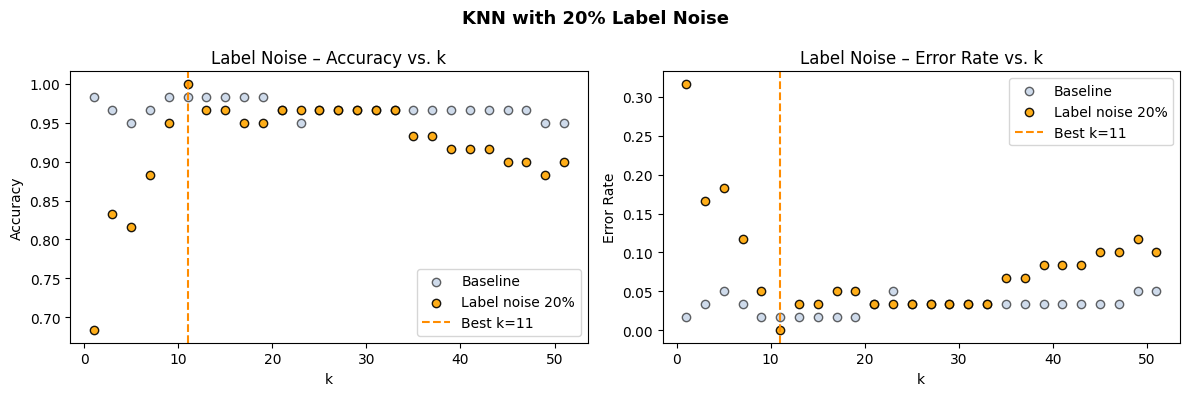

In [ ]:
# let us visualize the results for both baseline and noisy labels 
# side by side to compare the effects of label noise on accuracy and error rates
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_baseline['k'],     df_baseline['accuracy'],     color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[0].scatter(df_noisy_labels['k'], df_noisy_labels['accuracy'], color='orange',         edgecolors='k', alpha=0.9, label='Label noise 20%')
axes[0].axvline(best_noisy_labels['k'], color='darkorange', linestyle='--', label=f"Best k={int(best_noisy_labels['k'])}")
axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Label Noise – Accuracy vs. k')
axes[0].legend()

axes[1].scatter(df_baseline['k'],     df_baseline['error'],     color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[1].scatter(df_noisy_labels['k'], df_noisy_labels['error'], color='orange',         edgecolors='k', alpha=0.9, label='Label noise 20%')
axes[1].axvline(best_noisy_labels['k'], color='darkorange', linestyle='--', label=f"Best k={int(best_noisy_labels['k'])}")
axes[1].set_xlabel('k'); axes[1].set_ylabel('Error Rate')
axes[1].set_title('Label Noise – Error Rate vs. k')
axes[1].legend()

plt.suptitle('KNN with 20% Label Noise', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Best k (label noise): 11
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        33

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



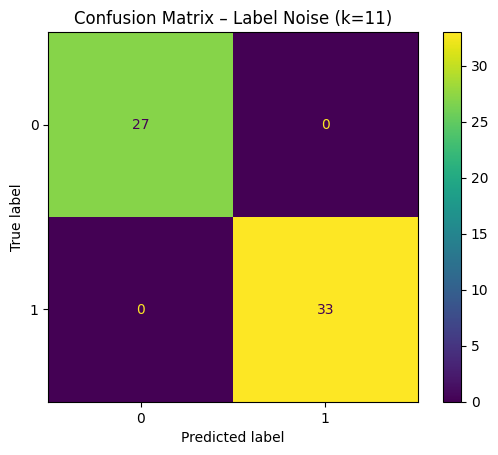

In [ ]:
# now we will fit the best model for noisy labels on the training set
best_k_nl = int(best_noisy_labels['k'])
knn_nl = KNeighborsClassifier(n_neighbors=best_k_nl)
knn_nl.fit(X_train_scaled, y_train_noisy)
y_pred_nl = knn_nl.predict(X_test_scaled)

print(f"Best k (label noise): {best_k_nl}")
print(classification_report(y_test, y_pred_nl))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nl)
plt.title(f'Confusion Matrix – Label Noise (k={best_k_nl})')
plt.show()

### A.5 Analysis with 4 Noisy Gaussian Features

In [ ]:
# now let's introduce some random noise features to the dataset and see how it affects the model performance
np.random.seed(42)

noise_cols = [f'noise_{i}' for i in range(1, 5)]
noise = pd.DataFrame(
    np.random.normal(0, 1, size=(len(X), 4)),
    columns=noise_cols,
    index=X.index
)
X_noisy = pd.concat([X, noise], axis=1)
print("Shape with noise features:", X_noisy.shape)
X_noisy.head()

Shape with noise features: (200, 6)


,x1,x2,noise_1,noise_2,noise_3,noise_4
0,0.914806,0.885118,0.496714,-0.138264,0.647689,1.523030
1,0.937075,0.517111,-0.234153,-0.234137,1.579213,0.767435
2,0.286140,0.851931,-0.469474,0.542560,-0.463418,-0.465730
3,0.830448,0.442796,0.241962,-1.913280,-1.724918,-0.562288
4,0.641746,0.157880,-1.012831,0.314247,-0.908024,-1.412304


In [15]:
# little but important implementation detail: split train-test first, then scale
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.3, random_state=42
)

sc_n = StandardScaler()
X_train_n_sc = sc_n.fit_transform(X_train_n)
X_test_n_sc  = sc_n.transform(X_test_n)

results_noisy_feat = [] # let us store the results for each k value in a list of dictionaries

for k in k_values: # create a loop to fit and evaluate the model for each k value
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_n_sc, y_train_n)
    acc = accuracy_score(y_test_n, knn.predict(X_test_n_sc))
    results_noisy_feat.append({'k': k, 'accuracy': acc, 'error': 1 - acc})

df_noisy_feat = pd.DataFrame(results_noisy_feat) # convert the list of dictionaries to a DataFrame
best_noisy_feat = df_noisy_feat.loc[df_noisy_feat['accuracy'].idxmax()]
print(df_noisy_feat.to_string(index=False))

 k  accuracy    error
 1  0.800000 0.200000
 3  0.866667 0.133333
 5  0.933333 0.066667
 7  0.900000 0.100000
 9  0.866667 0.133333
11  0.883333 0.116667
13  0.866667 0.133333
15  0.866667 0.133333
17  0.850000 0.150000
19  0.850000 0.150000
21  0.866667 0.133333
23  0.833333 0.166667
25  0.850000 0.150000
27  0.833333 0.166667
29  0.866667 0.133333
31  0.866667 0.133333
33  0.850000 0.150000
35  0.883333 0.116667
37  0.900000 0.100000
39  0.900000 0.100000
41  0.883333 0.116667
43  0.883333 0.116667
45  0.883333 0.116667
47  0.866667 0.133333
49  0.883333 0.116667
51  0.866667 0.133333


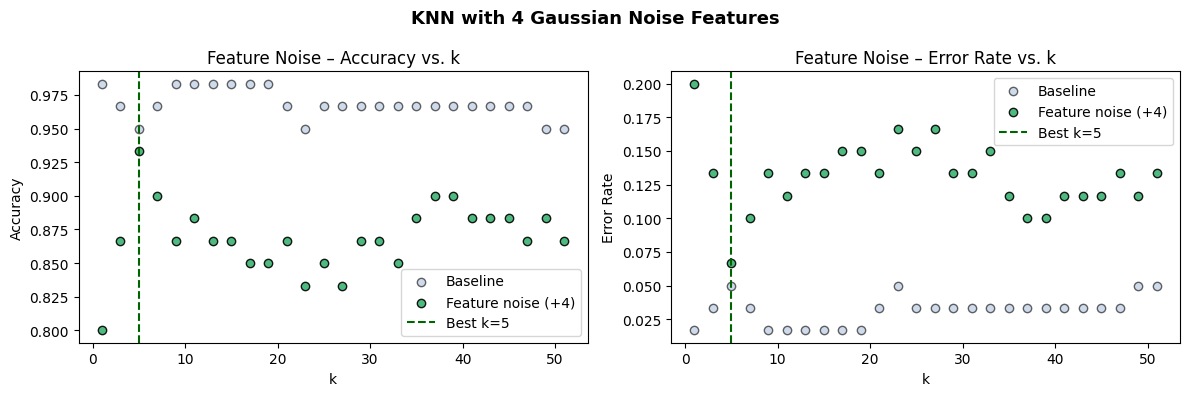

In [ ]:
# let us visualize the results for both baseline and noisy features 
# side by side to compare the effects of feature noise on accuracy and error rates
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_baseline['k'],   df_baseline['accuracy'],   color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[0].scatter(df_noisy_feat['k'], df_noisy_feat['accuracy'], color='mediumseagreen', edgecolors='k', alpha=0.9, label='Feature noise (+4)')
axes[0].axvline(best_noisy_feat['k'], color='darkgreen', linestyle='--', label=f"Best k={int(best_noisy_feat['k'])}")
axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Feature Noise – Accuracy vs. k')
axes[0].legend()

axes[1].scatter(df_baseline['k'],   df_baseline['error'],   color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[1].scatter(df_noisy_feat['k'], df_noisy_feat['error'], color='mediumseagreen', edgecolors='k', alpha=0.9, label='Feature noise (+4)')
axes[1].axvline(best_noisy_feat['k'], color='darkgreen', linestyle='--', label=f"Best k={int(best_noisy_feat['k'])}")
axes[1].set_xlabel('k'); axes[1].set_ylabel('Error Rate')
axes[1].set_title('Feature Noise – Error Rate vs. k')
axes[1].legend()

plt.suptitle('KNN with 4 Gaussian Noise Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Best k (feature noise): 5
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        27
           1       0.89      1.00      0.94        33

    accuracy                           0.93        60
   macro avg       0.95      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



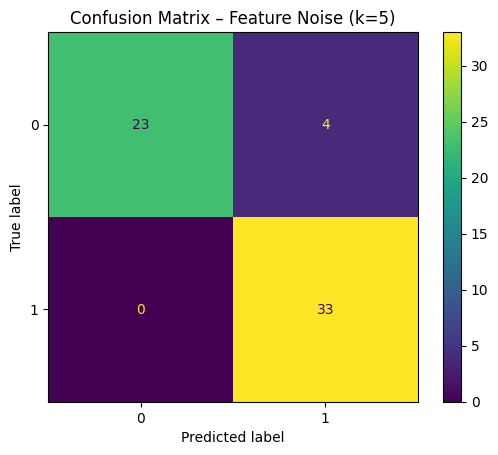

In [ ]:
# now we will fit the best model for noisy features on the training set
best_k_fn = int(best_noisy_feat['k'])
knn_fn = KNeighborsClassifier(n_neighbors=best_k_fn)
knn_fn.fit(X_train_n_sc, y_train_n)
y_pred_fn = knn_fn.predict(X_test_n_sc)

# let us visualize the results for both baseline and noisy features
print(f"Best k (feature noise): {best_k_fn}")
print(classification_report(y_test_n, y_pred_fn))
ConfusionMatrixDisplay.from_predictions(y_test_n, y_pred_fn)
plt.title(f'Confusion Matrix – Feature Noise (k={best_k_fn})')
plt.show()

---
## Part B – Assignment 5: 10-Fold Cross-Validation with GridSearchCV

We now perform model selection using **10-fold stratified cross-validation** on the **training set only**. Scaling is handled inside a `Pipeline` so that the scaler is re-fitted on each training fold and applied to the corresponding validation fold — eliminating any risk of data leakage.

### B.1 GridSearchCV on Cleaned Data

In [ ]:
# after the refinement of assignment 2, now we can 
# introduce pipeline structure, which will consist: scaler + KNN (hopefully prevents leakage across CV folds)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': k_values}

# we will use StratifiedKFold to ensure that each fold has a similar class distribution, which is important for classification tasks
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# scoring ='accuracy' is correct for classification
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring='accuracy',
    return_train_score=False,
    n_jobs=-1
)

# Fit on raw (unscaled) training data — pipeline handles scaling inside each fold)
grid_search.fit(X_train, y_train)

# Extract and organize the cross-validation results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['param_knn__n_neighbors', 'mean_test_score', 'std_test_score']]
cv_results.columns = ['k', 'mean_cv_accuracy', 'std_cv_accuracy'] # rename columns for better readability
cv_results['mean_cv_error'] = 1 - cv_results['mean_cv_accuracy'] # calculate mean CV error for better comparison with accuracy

# Extract the best k and corresponding CV accuracy
best_cv_k = grid_search.best_params_['knn__n_neighbors']
best_cv_acc = grid_search.best_score_

# let us visualize the results for cross-validation as well
print(f"Best k (10-fold CV): {best_cv_k}  |  Mean CV Accuracy: {best_cv_acc:.4f}")
print()
print(cv_results.to_string(index=False))

Best k (10-fold CV): 1  |  Mean CV Accuracy: 0.9714

 k  mean_cv_accuracy  std_cv_accuracy  mean_cv_error
 1          0.971429         0.047380       0.028571
 3          0.971429         0.047380       0.028571
 5          0.964286         0.047916       0.035714
 7          0.964286         0.047916       0.035714
 9          0.964286         0.047916       0.035714
11          0.964286         0.047916       0.035714
13          0.964286         0.047916       0.035714
15          0.964286         0.047916       0.035714
17          0.950000         0.032733       0.050000
19          0.950000         0.032733       0.050000
21          0.942857         0.028571       0.057143
23          0.921429         0.050000       0.078571
25          0.914286         0.053452       0.085714
27          0.921429         0.050000       0.078571
29          0.914286         0.053452       0.085714
31          0.914286         0.053452       0.085714
33          0.914286         0.053452       0.

### B.2 Visualisation – Cross-Validation Performance vs. k

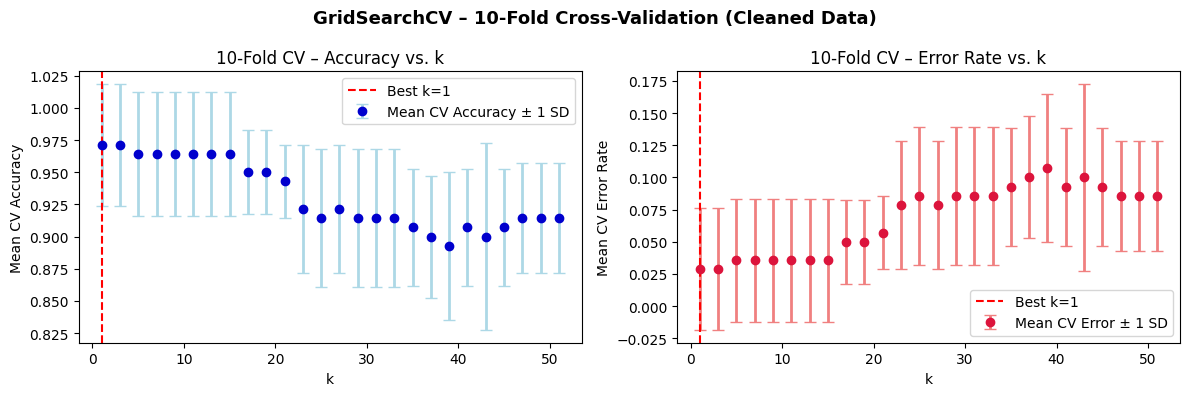

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CV accuracy
axes[0].errorbar(
    cv_results['k'], cv_results['mean_cv_accuracy'],
    yerr=cv_results['std_cv_accuracy'],
    fmt='o', color='mediumblue', ecolor='lightblue', elinewidth=2, capsize=4,
    label='Mean CV Accuracy ± 1 SD'
)
axes[0].axvline(best_cv_k, color='red', linestyle='--', label=f'Best k={best_cv_k}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Mean CV Accuracy')
axes[0].set_title('10-Fold CV – Accuracy vs. k')
axes[0].legend()

# CV error rate
axes[1].errorbar(
    cv_results['k'], cv_results['mean_cv_error'],
    yerr=cv_results['std_cv_accuracy'],
    fmt='o', color='crimson', ecolor='lightcoral', elinewidth=2, capsize=4,
    label='Mean CV Error ± 1 SD'
)
axes[1].axvline(best_cv_k, color='red', linestyle='--', label=f'Best k={best_cv_k}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Mean CV Error Rate')
axes[1].set_title('10-Fold CV – Error Rate vs. k')
axes[1].legend()

plt.suptitle('GridSearchCV – 10-Fold Cross-Validation (Cleaned Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### B.3 Side-by-Side Comparison: Test-Set vs. Cross-Validation

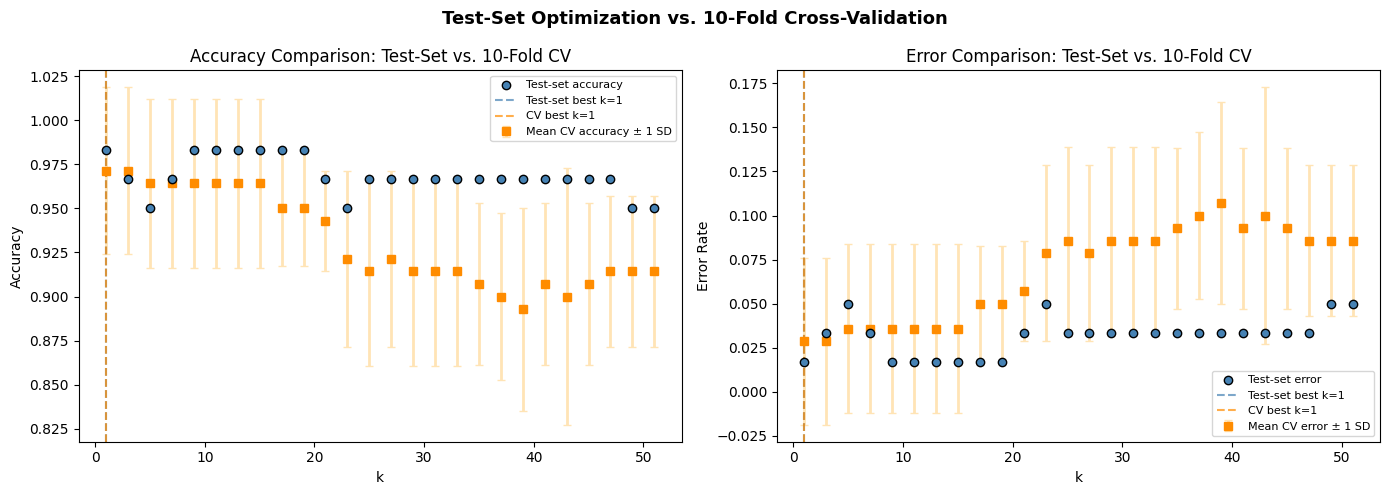

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].scatter(
    df_baseline['k'], df_baseline['accuracy'],
    color='steelblue', edgecolors='k', zorder=3, label='Test-set accuracy'
)
axes[0].errorbar(
    cv_results['k'], cv_results['mean_cv_accuracy'],
    yerr=cv_results['std_cv_accuracy'],
    fmt='s', color='darkorange', ecolor='moccasin', elinewidth=2, capsize=3,
    zorder=2, label='Mean CV accuracy ± 1 SD'
)
axes[0].axvline(best_baseline['k'], color='steelblue', linestyle='--', alpha=0.7,
                label=f"Test-set best k={int(best_baseline['k'])}")
axes[0].axvline(best_cv_k, color='darkorange', linestyle='--', alpha=0.7,
                label=f"CV best k={best_cv_k}")
axes[0].set_xlabel('k')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison: Test-Set vs. 10-Fold CV')
axes[0].legend(fontsize=8)

# Error rate comparison 
axes[1].scatter(
    df_baseline['k'], df_baseline['error'],
    color='steelblue', edgecolors='k', zorder=3, label='Test-set error'
)
axes[1].errorbar(
    cv_results['k'], cv_results['mean_cv_error'],
    yerr=cv_results['std_cv_accuracy'],
    fmt='s', color='darkorange', ecolor='moccasin', elinewidth=2, capsize=3,
    zorder=2, label='Mean CV error ± 1 SD'
)
axes[1].axvline(best_baseline['k'], color='steelblue', linestyle='--', alpha=0.7,
                label=f"Test-set best k={int(best_baseline['k'])}")
axes[1].axvline(best_cv_k, color='darkorange', linestyle='--', alpha=0.7,
                label=f"CV best k={best_cv_k}")
axes[1].set_xlabel('k')
axes[1].set_ylabel('Error Rate')
axes[1].set_title('Error Comparison: Test-Set vs. 10-Fold CV')
axes[1].legend(fontsize=8)

plt.suptitle('Test-Set Optimization vs. 10-Fold Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### B.4 Final Evaluation on Test Set Using Best CV k

Best k selected by 10-fold CV: 1
Test accuracy with CV-selected k: 0.9833

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.97      1.00      0.99        33

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



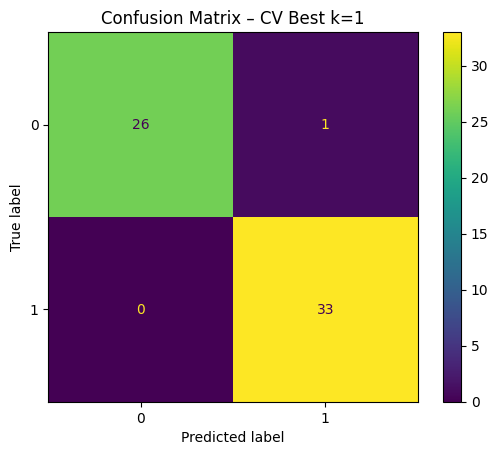

In [ ]:
# Re-train the best pipeline on the full training set and evaluate on the held-out test set
best_pipeline = grid_search.best_estimator_
y_pred_cv_best = best_pipeline.predict(X_test)

# let us visualize the results for both test-set optimization and CV-selected model
print(f"Best k selected by 10-fold CV: {best_cv_k}")
print(f"Test accuracy with CV-selected k: {accuracy_score(y_test, y_pred_cv_best):.4f}")
print()
print(classification_report(y_test, y_pred_cv_best))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cv_best)
plt.title(f'Confusion Matrix – CV Best k={best_cv_k}')
plt.show()

---
## Part C – Interpretation: Comparing Test-Set Optimization vs. Cross-Validation

### C.1 What do the two plots show?

**Test-set optimization (Assignment 2):**  
Each k is evaluated once against the single held-out test set. The resulting accuracy curve tends to be **noisy and irregular**: small random fluctuations in the test set can cause a particular k to look artificially better or worse than its true generalisation performance. Because the *same* test set is used both to tune and (implicitly) to select the best k, the evaluation is **optimistically biased** — we are effectively leaking information from the test set into our model-selection decision.

**10-fold cross-validation (Assignment 5):**  
The training data is split into 10 folds. For every candidate k, the model is trained on 9 folds and validated on the remaining fold, rotating until every fold has served as the validation set once. The reported score is the **mean accuracy across all 10 folds**, and the standard deviation (shown as error bars) quantifies the **variability** of the estimate. This produces a **smoother, more stable** curve because averaging over 10 different validation subsets reduces the influence of any single unlucky or lucky split.

### C.2 Key differences observed

| Aspect | Test-set optimisation | 10-fold CV |
|---|---|---|
| Curve shape | Noisy / irregular | Smoother, with a clearer trend |
| Best k selected | May vary with random seed | More stable and reliable |
| Risk of overfitting to evaluation data | **Yes** – test set used for selection | **No** – test set is never seen during selection |
| Uncertainty quantified? | No | Yes (std bars) |

### C.3 Why does cross-validation produce a smoother curve?

When we evaluate each k on a **single** test split, the resulting accuracy reflects both the model's true generalisation ability *and* the random particularities of that specific split (e.g., which samples ended up in test). With only ~30% of the data as test, this sampling noise is substantial.  

Cross-validation averages over 10 non-overlapping validation folds, so random fluctuations partially cancel out. The mean CV score is a **lower-variance estimator** of the true generalisation performance, which is why the curve is smoother and the optimal k it selects is more trustworthy.

### C.4 Importance of the Pipeline

In Assignment 2 the scaler was fitted on the full training set and then the same scaled data was used in every fold — this is a subtle form of **data leakage**: the scaler has already seen the validation fold's statistics. In Assignment 5 we wrap the scaler and the KNN model inside a `sklearn.pipeline.Pipeline`. During each CV iteration, the scaler is re-fitted **only on the 9 training folds** and then applied to the held-out fold. This makes the evaluation properly unbiased.

### C.5 Conclusion

Cross-validation is the methodologically correct approach for hyperparameter selection. It:
- Produces more **reliable and stable** estimates of generalisation performance.
- Prevents **test-set leakage** during model selection.
- Provides **uncertainty estimates** (std) alongside the mean performance.
- Allows the held-out test set to serve its intended purpose — an **unbiased final assessment** of the chosen model — rather than being inadvertently used during tuning.

In [22]:
!jupyter nbconvert --to html MLS2_A05_Somuncu.ipynb

[NbConvertApp] Converting notebook MLS2_A05_Somuncu.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 884710 bytes to MLS2_A05_Somuncu.html
